# E9: Quantifying human immune cell informative, discriminative, and noise dimensionality

**Started:** February 3, 2026

**Last updated:** February 3, 2026

**Research questions:** 1. How informative / noisy are different PCA and HVG dimensions in the task of identifying immune cell populations? 2. How discriminative are the PCA and HVG dimensions in separating CD4 and CD8 T cells?

**Methods:** Represent populations as multivariate normals, quantify how many z-scores populations/sub-popoulations are from each other. Z-score>=1 is informative/discriminative, <1 is not.

**Hypothesis:** 1. >25% of dimensions will be informative for cell type. 2. 5-10% of dimensions will be discriminative for CD4 vs CD8 T cells.

**Conclusion:** Between B cells, endothelial cells, macrophages, and monocytes, 25.7% of dimension are informative (>1 SD apart). 16% of dimensions were discriminative for classical vs intermediate monocytes. Despite these reasonably informative/discriminative dimensions, cross-species pairing fails, which may be due to different cell subtype representation and tissue sources. We may need to control for both.

**Potential Next Steps:** Can we successfully map across organisms in the same species? 

In [265]:
import numpy as np
from sklearn.decomposition import PCA
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy as sp
from scipy import sparse
import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import seaborn as sns
import random
from speciesot_helpers import label_uniform_cell_type_row, \
                              top_n_organisms_from_species, \
                              cell_types_with_n_per_organism, \
                              sample_equal_cell_types, \
                              ot_between_organisms, \
                              calc_random_mean_std, \
                              test_train_split_adata, \
                              get_cell_type_from_index, \
                              create_label_to_sample_dicts, \
                              concat_index, \
                              show_cell_type_results, \
                              cell_type_knn_acc
from speciesot_simulation_helpers import run_ot, \
                                         compute_mapping_acc, \
                                         sublabel_match_rate_from_gw, \
                                         plot_got_best_matches_with_labels, \
                                         gw_seeded

### Informative dimensions in well-represented cell populations

In [4]:
human_dir = 'data/tabula_sapiens/'
mouse_dir = 'data/tabula_muris/'

In [5]:
human_adatas = top_n_organisms_from_species(human_dir, 8, 'human')
mouse_adatas = top_n_organisms_from_species(mouse_dir, 8, 'mouse')

In [32]:
n_samples = 200
mouse1_full, human1_full = sample_equal_cell_types(mouse_adatas[0], human_adatas[0], n_samples)

In [41]:
(human1_full.obs['shared_cell_type'].value_counts()>10).index

CategoricalIndex(['monocyte', 'macrophage', 'endothelial cell', 'B cell',
                  'T cell', 'erythrocyte', 'fibroblast', 'smooth muscle cell',
                  'basophil', 'plasma cell', 'mast cell'],
                 categories=['B cell', 'T cell', 'basophil', 'endothelial cell', ..., 'mast cell', 'monocyte', 'plasma cell', 'smooth muscle cell'], ordered=False, dtype='category', name='shared_cell_type')

In [49]:
human_vc = human1_full.obs['shared_cell_type'].value_counts()
human_geq10 = human_vc[(human_vc>10)].index.tolist()

In [54]:
human_10plus = human1_full[human1_full.obs['shared_cell_type'].isin(human_geq10)]

In [66]:
human_10plus.obsm['X_pca'].shape

(154, 50)

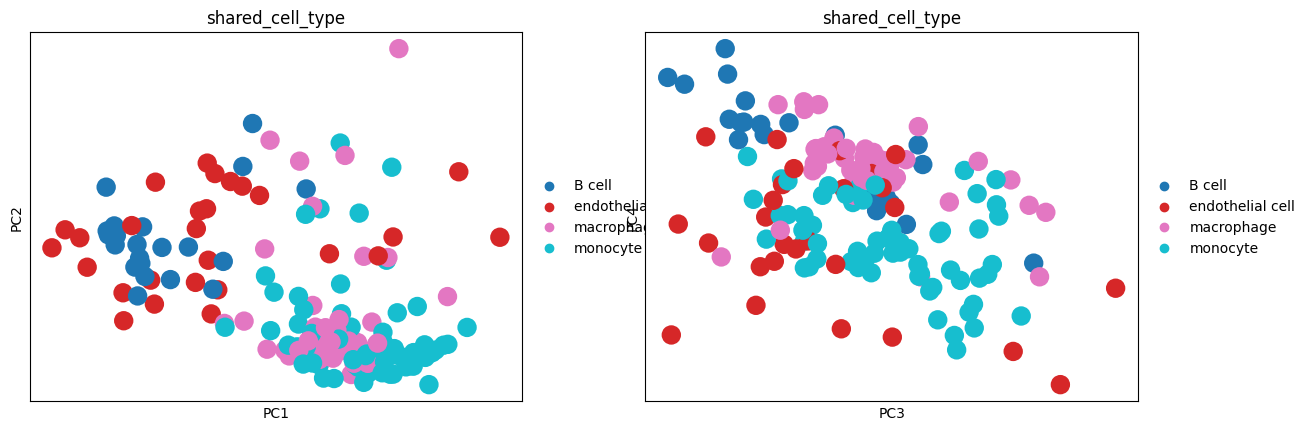

In [59]:
sc.pl.pca(human_10plus, color="shared_cell_type", dimensions=[(0, 1), (2, 3)])

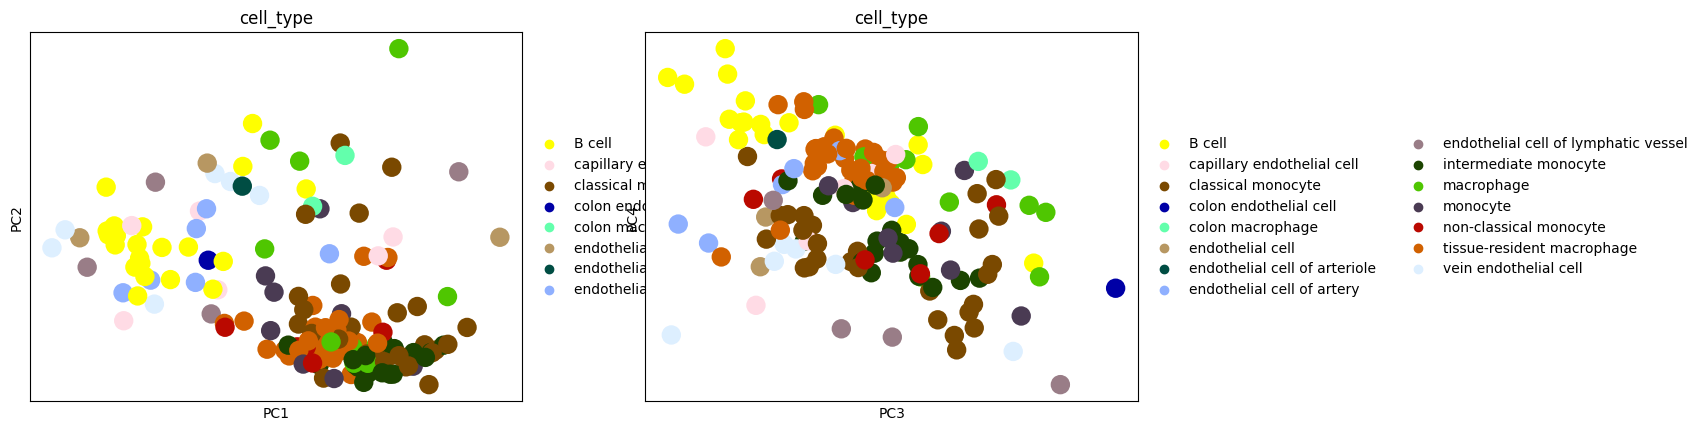

In [60]:
sc.pl.pca(human_10plus, color="cell_type", dimensions=[(0, 1), (2, 3)])

In [85]:
def informative_zscores(
    adata: "ad.AnnData",
    groupby: str = "shared_cell_type",
    n_pcs: int = 50,
    use_rep: str = "X_pca",
    ddof: int = 1,
    eps: float = 1e-12,
    return_index: bool = True,
) -> pd.DataFrame:
    """
    For each PCA dimension k, model each group as N(mean_gk, sd_gk).
    For every ordered pair (A,B), compute:
        z_A_to_B = |muA - muB| / sdA
        z_B_to_A = |muA - muB| / sdB
        z_min = min(z_A_to_B, z_B_to_A)
    Returns a (N*(N-1), n_pcs) matrix (ordered pairs, excluding self-pairs).
    If you truly want (N-1)^2 rows, that's only correct when N=2; for general N
    the natural interpretation of "two pairs" is ordered pairs (A,B) and (B,A),
    which yields N*(N-1) rows.

    Parameters
    ----------
    adata : AnnData
        Must contain PCA coordinates in `adata.obsm[use_rep]`.
    groupby : str
        Column in adata.obs with population labels.
    n_pcs : int
        Number of PCA dimensions (columns) to compute (default 50).
    use_rep : str
        Key in adata.obsm containing PCA coordinates (default "X_pca").
    ddof : int
        Degrees of freedom for std calculation (default 1 = sample std).
    eps : float
        Small value added to std to avoid division by zero.
    return_index : bool
        If True, returns a DataFrame indexed by (pop_A, pop_B); else returns numpy array.

    Returns
    -------
    pd.DataFrame or np.ndarray
        Shape: (N*(N-1), n_pcs). Rows = ordered population pairs (A,B), A!=B.
        Columns = PC1..PCn.
    """
    if groupby not in adata.obs:
        raise KeyError(f"{groupby!r} not found in adata.obs")
    if use_rep not in adata.obsm:
        raise KeyError(f"{use_rep!r} not found in adata.obsm (expected PCA coords)")

    X = adata.obsm[use_rep]
    if X.ndim != 2:
        raise ValueError(f"adata.obsm[{use_rep!r}] must be 2D, got shape {X.shape}")
    if X.shape[1] < n_pcs:
        raise ValueError(f"Requested n_pcs={n_pcs}, but {use_rep} has only {X.shape[1]} dims")

    X = np.asarray(X[:, :n_pcs], dtype=float)
    labels = adata.obs[groupby].astype("category")
    cats = list(labels.cat.categories)
    N = len(cats)
    if N < 2:
        raise ValueError(f"Need at least 2 populations in {groupby!r}, found {N}")

    # Compute per-group mean and std for each PC
    means = np.zeros((N, n_pcs), dtype=float)
    sds = np.zeros((N, n_pcs), dtype=float)

    for i, c in enumerate(cats):
        idx = (labels == c).to_numpy()
        Xi = X[idx]
        if Xi.shape[0] < 2 and ddof > 0:
            # sample std undefined; fall back to 0 then eps
            sd = np.zeros(n_pcs, dtype=float)
        else:
            sd = Xi.std(axis=0, ddof=ddof)
        means[i] = Xi.mean(axis=0)
        sds[i] = sd

    sds = np.maximum(sds, eps)

    # Build ordered pairs excluding self
    pair_index = []
    rows = []
    for ia in range(N):
        for ib in range(N):
            if ia == ib:
                continue
            mu_diff = np.abs(means[ia] - means[ib])  # (n_pcs,)
            z_a = mu_diff / sds[ia]
            z_b = mu_diff / sds[ib]
            z_min = np.minimum(z_a, z_b)
            rows.append(z_min)
            pair_index.append((cats[ia], cats[ib]))

    out = np.vstack(rows)  # (N*(N-1), n_pcs)

    if not return_index:
        return out

    colnames = [f"PC{i+1}" for i in range(n_pcs)]
    return pd.DataFrame(out, index=pd.MultiIndex.from_tuples(pair_index, names=["pop_A", "pop_B"]), columns=colnames)


# Example usage:
# zmat = pca_pairwise_min_zscores(adata, groupby="shared_cell_type", n_pcs=50)
# zmat.loc[("B_cell", "T_cell")].head()


In [86]:
celltype_z = informative_zscores(human_10plus)

In [87]:
np.sum(celltype_z>1, axis=1)

pop_A             pop_B           
B cell            endothelial cell     4
                  macrophage          19
                  monocyte            12
endothelial cell  B cell               4
                  macrophage          17
                  monocyte             5
macrophage        B cell              19
                  endothelial cell    17
                  monocyte            20
monocyte          B cell              12
                  endothelial cell     5
                  macrophage          20
dtype: int64

(array([6., 7., 8., 7., 8., 5., 4., 3., 1., 1.]),
 array([0.0352847 , 0.25063705, 0.46598939, 0.68134174, 0.89669408,
        1.11204643, 1.32739877, 1.54275112, 1.75810346, 1.97345581,
        2.18880815]),
 <BarContainer object of 10 artists>)

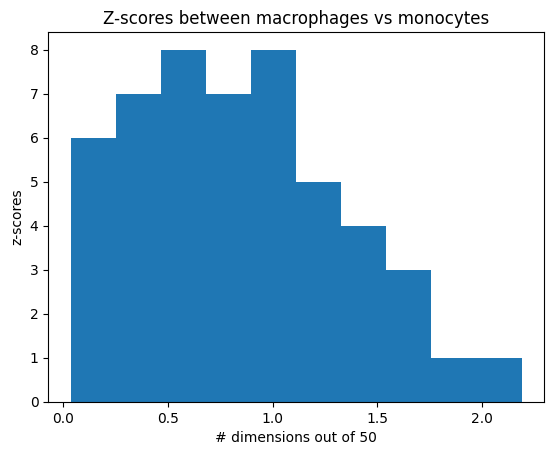

In [117]:
plt.title('Z-scores between macrophages vs monocytes')
plt.xlabel('# dimensions out of 50')
plt.ylabel('z-scores')
plt.hist(celltype_z.iloc[8,:], bins=10)

In [88]:
np.sum(np.sum(celltype_z>=1.0)) / (celltype_z.shape[0]*celltype_z.shape[1])

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


np.float64(0.25666666666666665)

Between B cells, endothelial cells, macrophages, and monocytes, 25.7% of dimension are informative (>1 SD apart) and thus 74.3% are noisy. Endothelial cells appear to have largest SD and the least number of discriminative dims (8%, 34%, 10%); macrophages have the most (38%, 34%, 40%).

### Discriminative dimensions for classical vs intermediate monocytes

In [92]:
human_monocytes = human_10plus[human_10plus.obs['cell_type'].isin(['classical monocyte','intermediate monocyte'])]

In [89]:
human_10plus.obs['cell_type'].value_counts()

cell_type
tissue-resident macrophage              31
classical monocyte                      27
B cell                                  22
intermediate monocyte                   21
macrophage                              10
monocyte                                 8
capillary endothelial cell               6
non-classical monocyte                   6
endothelial cell of artery               6
vein endothelial cell                    6
endothelial cell of lymphatic vessel     4
endothelial cell                         3
colon macrophage                         2
endothelial cell of arteriole            1
colon endothelial cell                   1
Name: count, dtype: int64

In [96]:
mono_zscores = informative_zscores(human_monocytes, groupby='cell_type')

In [99]:
np.sum(mono_zscores>1, axis=1)

pop_A                  pop_B                
classical monocyte     intermediate monocyte    8
intermediate monocyte  classical monocyte       8
dtype: int64

In [103]:
mono_zscores

,,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
pop_A,pop_B,,,,,,,,,,,,,,,,,,,,,
classical monocyte,intermediate monocyte,0.037761,0.691045,0.037714,0.345729,0.988466,0.702311,0.774492,0.206083,0.017963,1.160163,...,1.119654,0.629109,0.592756,0.144618,0.365707,1.366255,0.637869,0.043352,0.548059,0.18392
intermediate monocyte,classical monocyte,0.037761,0.691045,0.037714,0.345729,0.988466,0.702311,0.774492,0.206083,0.017963,1.160163,...,1.119654,0.629109,0.592756,0.144618,0.365707,1.366255,0.637869,0.043352,0.548059,0.18392


In [102]:
np.mean(mono_zscores,axis=1)

pop_A                  pop_B                
classical monocyte     intermediate monocyte    0.553379
intermediate monocyte  classical monocyte       0.553379
dtype: float64

(array([8., 9., 5., 4., 8., 4., 3., 2., 4., 3.]),
 array([0.01796322, 0.15423895, 0.29051468, 0.42679041, 0.56306614,
        0.69934187, 0.8356176 , 0.97189333, 1.10816906, 1.24444479,
        1.38072052]),
 <BarContainer object of 10 artists>)

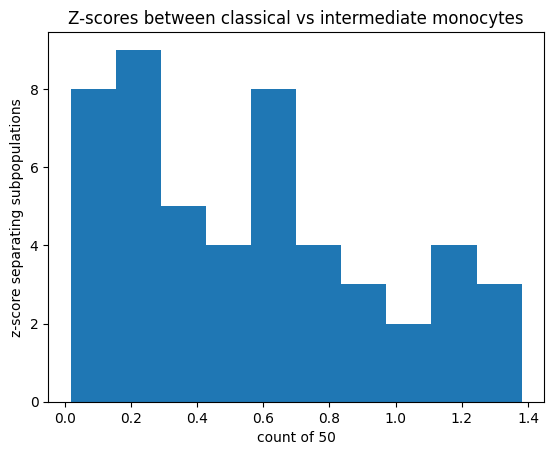

In [112]:
plt.title('Z-scores between classical vs intermediate monocytes')
plt.xlabel('count of 50')
plt.ylabel('z-score separating subpopulations')
plt.hist(mono_zscores.iloc[0,:], bins=10)

16% of dimensions are discriminative for classical versus intermediate monocytes.

### Informative and discriminative dims for top 50 HVGs 

In [121]:
human_monocytes

View of AnnData object with n_obs × n_vars = 48 × 61759
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'scvi_leiden_res05_compartment', 'sample_number', 'suspension_type', 'tissue_type', 'disease_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity',

In [144]:
def store_top_hvgs(
    adata,
    n_top_genes=2000,
    obsm_key="X_hvg",
    uns_key="hvg_genes",
    flavor="cell_ranger",
    min_cells=5,
    min_counts=None,
    layer=None,
):
    X = adata.layers[layer] if layer is not None else adata.X

    # --- gene filtering to avoid bin-edge issues
    if sparse.issparse(X):
        gene_nnz = np.asarray((X > 0).sum(axis=0)).ravel()
        gene_sum = np.asarray(X.sum(axis=0)).ravel()
    else:
        gene_nnz = (X > 0).sum(axis=0)
        gene_sum = X.sum(axis=0)

    keep = gene_nnz >= min_cells
    if min_counts is not None:
        keep &= gene_sum >= min_counts
    if keep.sum() == 0:
        keep = np.ones(adata.n_vars, dtype=bool)

    adata_tmp = adata[:, keep].copy()

    try:
        sc.pp.highly_variable_genes(
            adata_tmp,
            n_top_genes=min(n_top_genes, adata_tmp.n_vars),
            flavor=flavor,
            subset=False,
            inplace=True,
            layer=layer,
        )

        hvg_df = adata_tmp.var.loc[adata_tmp.var["highly_variable"]].copy()
        if "highly_variable_rank" in hvg_df.columns:
            hvg_df = hvg_df.sort_values("highly_variable_rank")
        else:
            hvg_df = hvg_df.sort_values("dispersions_norm", ascending=False)

        hvg_genes = hvg_df.index.to_numpy()

    except Exception:
        # fallback: variance-based HVGs
        Xf = adata_tmp.layers[layer] if layer is not None else adata_tmp.X
        if sparse.issparse(Xf):
            mean = np.asarray(Xf.mean(axis=0)).ravel()
            mean_sq = np.asarray(Xf.power(2).mean(axis=0)).ravel()
            var = mean_sq - mean**2
        else:
            var = Xf.var(axis=0)

        order = np.argsort(-var)
        hvg_genes = adata_tmp.var_names[
            order[: min(n_top_genes, adata_tmp.n_vars)]
        ].to_numpy()

    # --- store results on original adata
    adata.uns[uns_key] = hvg_genes

    X_hvg = adata[:, hvg_genes].X
    if sparse.issparse(X_hvg):
        X_hvg = X_hvg.toarray()
    else:
        X_hvg = np.asarray(X_hvg)

    adata.obsm[obsm_key] = X_hvg

    return adata

In [145]:
store_top_hvgs(human_10plus, n_top_genes=50)

AnnData object with n_obs × n_vars = 154 × 61759
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'scvi_leiden_res05_compartment', 'sample_number', 'suspension_type', 'tissue_type', 'disease_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'devel

In [150]:
human10_hvg_zscores = informative_zscores(human_10plus, groupby='shared_cell_type', use_rep='X_hvg')

In [155]:
np.sum(np.sum(human10_hvg_zscores>1, axis=1)) / (human10_hvg_zscores.shape[0]*human10_hvg_zscores.shape[1])

np.float64(0.17666666666666667)

17.7% of dimensions are informative for top 50 HVGs. Less than PCA dimensions.

In [156]:
# Discriminative dimensions using top 50 HVGs

In [158]:
store_top_hvgs(human_monocytes, n_top_genes=50)

/tmp/ipykernel_733894/2047449808.py:63: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[uns_key] = hvg_genes


AnnData object with n_obs × n_vars = 48 × 61759
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'scvi_leiden_res05_compartment', 'sample_number', 'suspension_type', 'tissue_type', 'disease_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'develo

In [159]:
mono_hvg_zscores = informative_zscores(human_monocytes, groupby='cell_type', use_rep='X_hvg')

In [160]:
np.sum(np.sum(mono_hvg_zscores>1, axis=1)) / (mono_hvg_zscores.shape[0]*mono_hvg_zscores.shape[1])

np.float64(0.02)

2% of dimensions are discriminative using HVGs, meaning only 1 gene out of the top 50 HVGs. Using PCA dims looks superior.

### Repeating with PCA dims for mice

In [165]:
mouse_geq10 = human_geq10  # same due to sampling procedure

In [166]:
mouse_10plus = mouse1_full[mouse1_full.obs['shared_cell_type'].isin(mouse_geq10)]

In [174]:
mouse_zscores = informative_zscores(mouse_10plus, groupby='shared_cell_type', use_rep='X_pca')

In [175]:
mouse_zscores

PC1       PC2       PC3       PC4  \
pop_A            pop_B                                                      
B cell           endothelial cell  6.458886  1.588801  1.562667  5.794509   
                 macrophage        3.161114  2.424609  2.381464  1.995725   
                 monocyte          2.770442  2.587623  1.926845  0.963709   
endothelial cell B cell            6.458886  1.588801  1.562667  5.794509   
                 macrophage        5.630532  1.318606  0.540396  5.338795   
                 monocyte          5.775148  1.315425  0.764646  5.574451   
macrophage       B cell            3.161114  2.424609  2.381464  1.995725   
                 endothelial cell  5.630532  1.318606  0.540396  5.338795   
                 monocyte          0.551873  0.028541  1.477802  1.048881   
monocyte         B cell            2.770442  2.587623  1.926845  0.963709   
                 endothelial cell  5.775148  1.315425  0.764646  5.574451   
                 macrophage        0.551873  0.028541  1.477802  1.048881   

                                        PC5       PC6       PC7       PC8  \
pop_A            pop_B                                                      
B cell           endothelial cell  3.272029  2.832919  0.684225  1.805296   
                 macrophage        1.183803  4.334842  2.287011  2.404266   
                 monocyte          0.166067  3.903185  1.241314  2.435036   
endothelial cell B cell            3.272029  2.832919  0.684225  1.805296   
                 macrophage        3.408690  2.673647  0.581520  0.487572   
                 monocyte          3.288423  1.296948  0.234874  0.470708   
macrophage       B cell            1.183803  4.334842  2.287011  2.404266   
                 endothelial cell  3.408690  2.673647  0.581520  0.487572   
                 monocyte          1.041794  2.046054  1.475102  0.047142   
monocyte         B cell            0.166067  3.903185  1.241314  2.435036   
                 endothelial cell  3.288423  1.296948  0.234874  0.470708   
                 macrophage        1.041794  2.046054  1.475102  0.047142   

                                        PC9      PC10  ...      PC41  \
pop_A            pop_B                                 ...             
B cell           endothelial cell  3.235077  3.764455  ...  0.200324   
                 macrophage        2.667022  3.403167  ...  0.644156   
                 monocyte          2.674740  3.077232  ...  0.251291   
endothelial cell B cell            3.235077  3.764455  ...  0.200324   
                 macrophage        1.750557  0.655606  ...  1.088436   
                 monocyte          1.582880  1.585164  ...  0.065690   
macrophage       B cell            2.667022  3.403167  ...  0.644156   
                 endothelial cell  1.750557  0.655606  ...  1.088436   
                 monocyte          0.021804  0.591454  ...  1.668332   
monocyte         B cell            2.674740  3.077232  ...  0.251291   
                 endothelial cell  1.582880  1.585164  ...  0.065690   
                 macrophage        0.021804  0.591454  ...  1.668332   

                                       PC42      PC43      PC44      PC45  \
pop_A            pop_B                                                      
B cell           endothelial cell  0.538015  0.359464  0.286074  0.159531   
                 macrophage        0.145544  1.560494  0.769970  0.929429   
                 monocyte          0.073549  0.980896  1.089435  1.048489   
endothelial cell B cell            0.538015  0.359464  0.286074  0.159531   
                 macrophage        0.607349  1.310767  0.755588  2.239243   
                 monocyte          0.946395  0.332834  1.723699  2.611197   
macrophage       B cell            0.145544  1.560494  0.769970  0.929429   
                 endothelial cell  0.607349  1.310767  0.755588  2.239243   
                 monocyte          0.707573  1.079541  0.498833  0.346285   
monocyte         B cell   

(array([23., 10., 10.,  0.,  3.,  2.,  0.,  0.,  1.,  1.]),
 array([0.01153215, 0.65626752, 1.30100289, 1.94573826, 2.59047363,
        3.235209  , 3.87994437, 4.52467974, 5.16941511, 5.81415048,
        6.45888585]),
 <BarContainer object of 10 artists>)

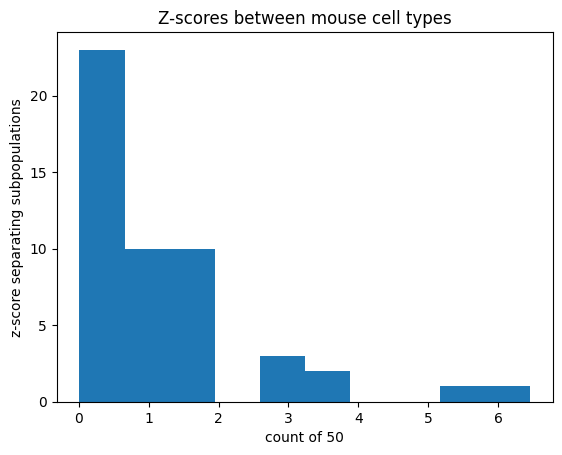

In [176]:
plt.title('Z-scores between mouse cell types')
plt.xlabel('count of 50')
plt.ylabel('z-score separating subpopulations')
plt.hist(mouse_zscores.iloc[0,:], bins=10)

In [177]:
np.sum(np.sum(mouse_zscores>1, axis=1)) / (mouse_zscores.shape[0]*mouse_zscores.shape[1])

np.float64(0.5033333333333333)

50.3% of mouse dimensions are informative

In [179]:
### Looking at monocyte discriminative dimensions

In [180]:
mouse_monocytes = mouse_10plus[mouse_10plus.obs['cell_type'].isin(['classical monocyte','intermediate monocyte'])]

In [183]:
mouse_monoctyes_z = informative_zscores(mouse_monocytes, groupby='cell_type', use_rep='X_pca')

In [185]:
np.sum(mouse_monoctyes_z>1, axis=1)

pop_A                  pop_B                
classical monocyte     intermediate monocyte    5
intermediate monocyte  classical monocyte       5
dtype: int64

10% of mouse dimensions are informative for discriminating intermediate and classical monocytes.

### Alignment of mouse and human cell populations with Gromov OT (unanchored first)

In [194]:
num_cells = mouse_10plus.obsm['X_pca'].shape[0]

In [199]:
mouseX = mouse_10plus.obsm['X_pca']
humanX = human_10plus.obsm['X_pca']

In [203]:
mouse_labels = mouse_10plus.obs['shared_cell_type'].tolist()
human_labels = human_10plus.obs['shared_cell_type'].tolist()

In [197]:
gw = run_ot(mouseX, humanX, num_cells, epsilon=0.1)

In [198]:
gw

array([[9.32603735e-120, 0.00000000e+000, 0.00000000e+000, ...,
        1.00822577e-233, 0.00000000e+000, 6.73488454e-127],
       [0.00000000e+000, 5.59030888e-008, 2.85154374e-003, ...,
        0.00000000e+000, 1.55366929e-011, 0.00000000e+000],
       [0.00000000e+000, 1.02865016e-096, 1.84665721e-102, ...,
        0.00000000e+000, 1.20157542e-021, 0.00000000e+000],
       ...,
       [0.00000000e+000, 1.29763292e-170, 2.27600418e-144, ...,
        1.62839715e-121, 1.07026966e-151, 0.00000000e+000],
       [0.00000000e+000, 9.34084398e-015, 1.05577585e-025, ...,
        0.00000000e+000, 2.19153380e-015, 0.00000000e+000],
       [1.68028661e-033, 0.00000000e+000, 0.00000000e+000, ...,
        6.43724447e-315, 0.00000000e+000, 4.44433738e-027]],
      shape=(154, 154))

In [207]:
compute_mapping_acc(gw, mouse_labels, human_labels)

0.35714285714285715

(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'GOT argmax matches with class consistency'}, xlabel='dim 0', ylabel='dim 1'>,
 array([ 13,  48,  25, 118,  10,  85, 125,  18,  96,   3,  62,  90, 104,
         36,  41,  84,  79, 117,  87, 115,  68,  52,  16,  45, 105,  17,
        150, 116,   7,  12,  49,  14,  43,   8, 108, 131,  76,  97,  33,
         89,  38,   1,  55, 133,  19, 109, 110, 129,   5,  20,  94, 139,
        135, 146, 112,  42, 143,  24,  50, 142, 120,  95,  44, 153, 119,
         23, 151,  72,   2,  37,  57,  73,  39, 147, 113,  77,  34,  82,
         53,  32,  54,  58,  93, 145,  92,  61,  59,  11,  80,  91, 121,
        134,  50, 102, 128, 127,  35,  30,  78,  81, 122,  71, 124, 138,
          0,   9,  22,  49,  74,  47,  88,  60,  70,  65, 107, 123, 126,
        144,  69,   4,  56,  31, 136,  40, 152, 148, 130,  51, 140,  73,
         98, 137, 114,  66, 106, 141, 103,  64, 100, 149,  46, 132,  47,
         29,  27,  99,  75,  56,  21,  26,  67,  63,  52,

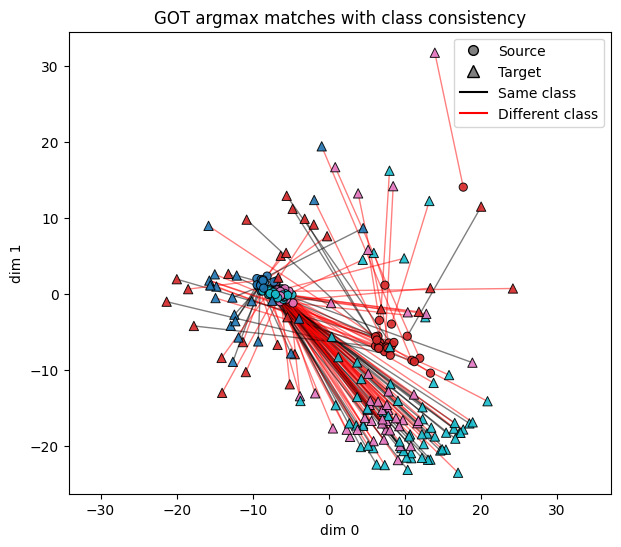

In [210]:
plot_got_best_matches_with_labels(mouseX, humanX, gw, mouse_labels, human_labels)

### Attempting mouse-human pairing with initialization anchored OT

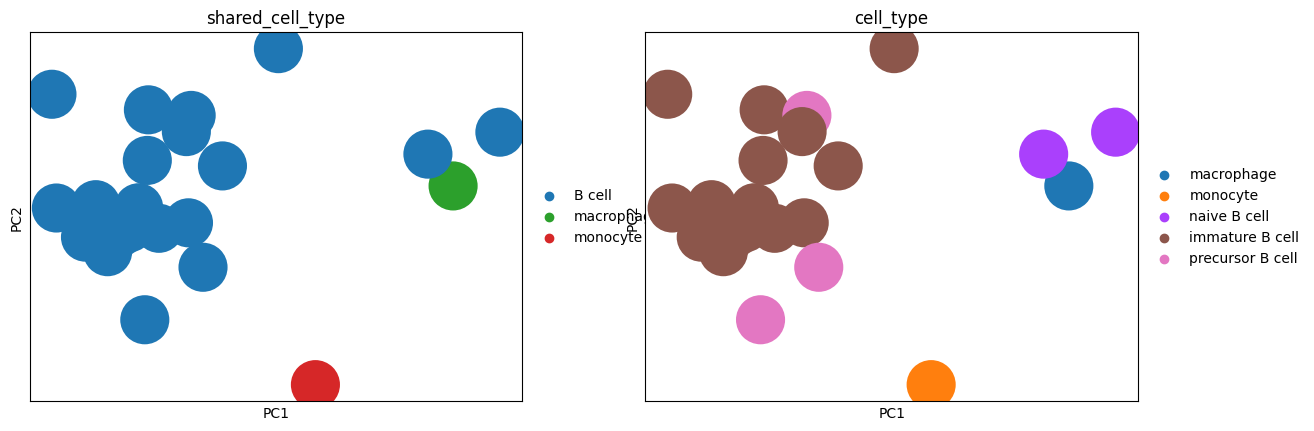

In [233]:
sc.pl.pca(mouse_10plus[mouse_10plus.obs['tissue']=='bone marrow'], color=['shared_cell_type','cell_type'])

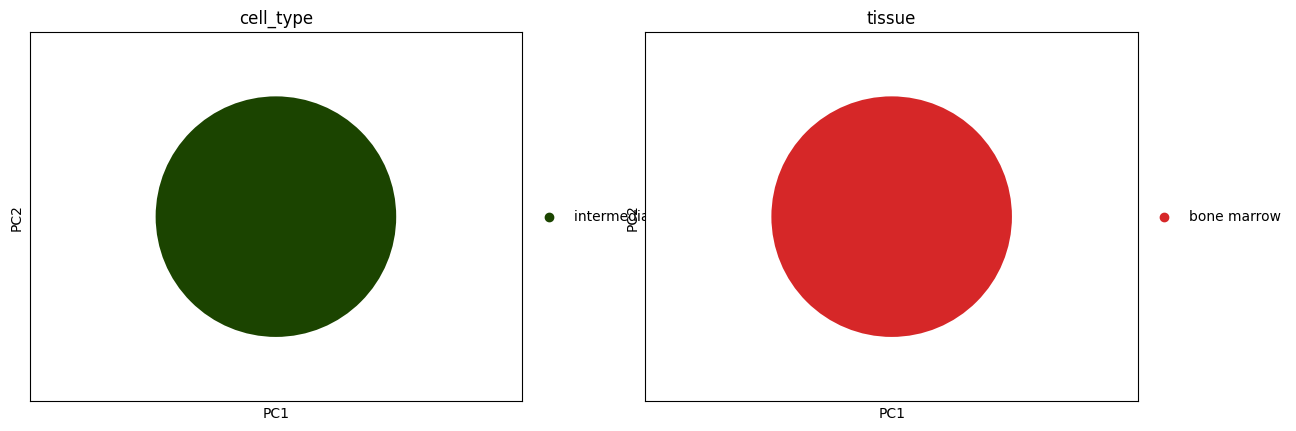

In [229]:
sc.pl.pca(human_10plus[human_10plus.obs['tissue']=='bone marrow'], color=['cell_type','tissue'])

In [251]:
mouse_10plus_bm = mouse_10plus[mouse_10plus.obs['tissue']=='bone marrow']
mouse_bm_monocyte = mouse_10plus_bm[mouse_10plus_bm.obs['cell_type']=='monocyte']
mouse_anchor_name = mouse_bm_monocyte.obs.index[0]
mouse_anchor_idx = mouse_10plus.obs_names.get_loc(mouse_anchor_name)

In [252]:
human_10plus_bm = human_10plus[human_10plus.obs['tissue']=='bone marrow']
human_bm_monocyte = human_10plus_bm[human_10plus_bm.obs['cell_type']=='intermediate monocyte']
human_anchor_name = human_bm_monocyte.obs.index[0]
human_anchor_idx = human_10plus.obs_names.get_loc(human_anchor_name)

In [253]:
human_anchor_idx

112

In [256]:
gws = gw_seeded(mouseX, humanX, num_cells, [mouse_anchor_idx], [human_anchor_idx], epsilon=0.1)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'GOT argmax matches with class consistency'}, xlabel='dim 0', ylabel='dim 1'>,
 array([ 13,  48,  25, 118,  10,  85, 125,  18,  96,   3,  62,  90, 104,
         36,  41,  84,  79, 117,  87, 115,  68,  52,  16,  45,  54,  17,
        150, 116,   7,  12,  49,  14,  43,   8, 108, 131,  76,  97,  33,
         89,  38,   1,  55, 133,  19, 109, 110, 129,   5,  20,  94, 139,
         84, 146, 112,  42, 143,  24,  50, 142, 120,  95,  44, 153, 119,
         23, 151,  72,   2,  37,  57,  73,  39, 147, 113,  77,  34,  82,
         53,  32,  54,  58,  93, 145,  92,  61,  59, 101,  80,  91, 121,
        134,  50, 102, 128, 127,  35,  30,  78,  81, 122,  71, 124, 138,
          0,   9,  22,  49,  74,  47,  88,  60,  70,  65, 107, 123, 126,
        144,  69,   4,  56,  31, 136,  40, 152, 148, 130,  51, 140,  73,
         98, 137, 114,  66, 106, 141, 103,  64, 100, 149,  46, 132,  47,
         29,   9,  99,  75,  56,  21,  26,  67,  63,  52,

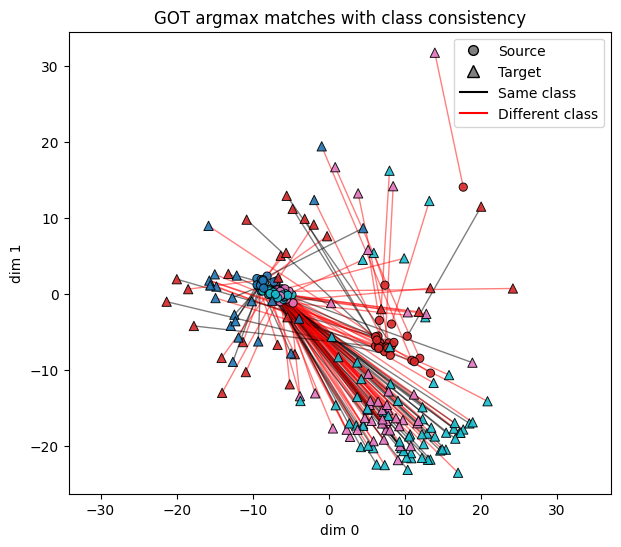

In [257]:
plot_got_best_matches_with_labels(mouseX, humanX, gws, mouse_labels, human_labels)

In [258]:
compute_mapping_acc(gws, mouse_labels, human_labels)

0.35714285714285715

Both unanchored and anchored GW resulted in 36% cell type matching accuracy.